### Grades Model

In [7]:
import pandas as pd
import numpy as np

In [8]:
import warnings
warnings.filterwarnings('ignore')

### I. Description of the Variables and Structure of the Scoring System
##### Structure of Scoring Equations and Series of Variables comprazing the Scoring Models:

There are three pieces to a catalog scoring equation.<br>
1.	Probability of a Customer Purchasing, Next Year (30%).<br>
2.	Amount a Customer Will Spend if Customer Purchases, Next Year ($100.00).<br>
3.	Percentage of Next Year’s Spend That is Organic (Non-Catalog) (60%).<br>

The catalog score is derived as follows:<br>
•	(Probability of Purchase) * (Predicted Spend) * (1 – Predicted Organic Percentage).<br>


A series of variables comprise the scoring models.<br>
•	ROOT_REC = Square root of months since last purchase.<br>
•	HST_FREQ = Number of life-to-date purchases.<br>
•	HST_DEMD = Life-to-Date Demand spent.<br>
•	HST_AOV = (HST_DEMD / HST_FREQ).<br>
•	HST_AOV000 = HST_AOV / 1000.<br>
•	Merchandise Indicators … 1 = Ever Bought, 0 = Never Bought. Derived from the High Level Category Variable Sent to Me.<br>
o	MR00 = All Other Merchandise<br>
o	MR01 = Adjustments<br>
o	MR02 = Bibles<br>
o	MR03 = Books<br>
o	MR04 = Church Supplies<br>
o	MR05 = Closeouts<br>
o	MR06 = Damaged<br>
o	MR07 = Downloads<br>
o	MR08 = Exclusives<br>
o	MR09 = Gifts<br>
o	MR10 = HomeSchool<br>
o	MR11 = Music<br>
o	MR12 = Videos<br>
•	Channel Indicators … 1 = Ever Bought, 0 = Never Bought. Derived from each attributed channel sent to me.<br>
o	HST_AFFI (affiliates)<br>
o	HST_CATG (catalog)<br>
o	HST_CATI (catalog insert)<br>
o	HST_EMAI (email)<br>
o	HST_SRCO (organic search)<br>
o	HST_OTHR (all other)<br>
o	HST_PBRN (paid search brand)<br>
o	HST_PNON (paid search non-branded)<br>
o	HST_SHOP (shopping / PLA).<br>
o	HST_TEXT (sms)<br>
o	HST_SOCI (social)<br>
•	HST_SHIP (sum all paid shipping, then divide by historical demand spent).<br>
•	HST_ORGN (sum all demand spent except for catalog attribution and catalog insert attribution, divide by sum of all demand spent).<br>
•	HST_CLICK = Sum of all email clicks, past year.<br>
•	HST_VISI = Sum of all website visits, past year.<br><br><br>
•	ROOT_ECL = Square Root of HST_CLCK.   !!!!Edit! Edit!!!!! Edit!!!!! Currently, EOOT_ECL<br>    <br> <br>
•	ROOT_VIS = Square Root of HST_VISI.<br>



#### I. Create List of Models for Predictions.
The list of models contains OLS models for each prediction.  The models are Python replication of grades code.  After the list is compiles, models on the list are used to make predictions and calculate customer grades.


##### 1.1 Read in file to train models

In [ ]:
# Read in files to build model: files inlude Variables and Grades to test the model
data = pd.read_csv('Table_Output.csv') # 10,000 file; includes variables and grades


In [4]:
df = data.copy()

In [5]:
df.shape

(10000, 48)

In [6]:
df= df.fillna(0)

In [7]:
df.columns

Index(['customerID', 'ROOT_REC', 'HST_FREQ', 'HST_DEMD', 'HST_AOV',
       'HST_AOV000', 'MR00', 'MR01', 'MR02', 'MR03', 'MR04', 'MR05', 'MR06',
       'MR07', 'MR08', 'MR09', 'MR10', 'MR11', 'MR12', 'HST_AFFI', 'HST_CATG',
       'HST_CATI', 'HST_EMAI', 'HST_SRCO', 'HST_OTHR', 'HST_PBRN', 'HST_PNON',
       'HST_SHOP', 'HST_TEXT', 'HST_SOCI', 'HST_SHIP', 'HST_ORGN', 'HST_CLICK',
       'HST_VISI', 'ROOT_ECL', 'ROOT_VIS', 'grade_brand', 'grade_catalog',
       'grade_catavg', 'grade_ship', 'grade_affiliate', 'grade_email',
       'grade_organicsearch', 'grade_paidbrand', 'grade_paidnonbrand',
       'grade_shopping', 'grade_text', 'grade_social'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 48 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           10000 non-null  int64  
 1   ROOT_REC             10000 non-null  float64
 2   HST_FREQ             10000 non-null  int64  
 3   HST_DEMD             10000 non-null  float64
 4   HST_AOV              10000 non-null  float64
 5   HST_AOV000           10000 non-null  float64
 6   MR00                 10000 non-null  int64  
 7   MR01                 10000 non-null  int64  
 8   MR02                 10000 non-null  int64  
 9   MR03                 10000 non-null  int64  
 10  MR04                 10000 non-null  int64  
 11  MR05                 10000 non-null  int64  
 12  MR06                 10000 non-null  int64  
 13  MR07                 10000 non-null  int64  
 14  MR08                 10000 non-null  int64  
 15  MR09                 10000 non-null  

In [121]:
pd.set_option('display.max_columns', None)


##### 1.2  Create Vectors for Logit Expressions for each prediction; add vectors to the data frame

In [122]:
# BRAND RESPONSE:
predr = (-0.790 - 0.387*df['ROOT_REC'] + 0.069*df['HST_FREQ'] - 0.075*df['HST_AOV000']
+ 0.035* df['MR00'] + 0.031*df['MR01'] + 0.244*df['MR03'] + 0.159*df['MR04'] + 0.058*df['MR05']
- 0.047*df['MR06'] - 0.045*df['MR07'] + 0.146*df['MR08'] + 0.022*df['MR09'] + 0.247*df['MR10']
+ 0.124*df['MR11'] + 0.100*df['MR12'] + 0.051*df['HST_AFFI'] + 0.494*df['HST_CATG']
+ 0.018*df['HST_CATI'] + 0.158*df['HST_EMAI'] + 0.081*df['HST_SRCO'] + 0.099*df['HST_OTHR']
+ 0.156*df['HST_PBRN'] + 0.103*df['HST_PNON'] - 0.075*df['HST_SHOP'] + 0.175*df['HST_TEXT']
+ 0.149*df['ROOT_ECL'] + 0.114*df['ROOT_VIS'] - 0.380*df['HST_ORGN'])
                                                            
# For Training/ Replicating Model only: add value of linear expression to the training data frame:
df['predr'] = predr

#predr = round(predr, 4)
#df['predr'] = np.exp(predr)/(1+np.exp(predr))                  


In [123]:
# BRAND SPEND:
# Calcualte brand spend and add variable to the data frame   
preds = 93.733 + 0.056*df['HST_DEMD'] + 7.724*df['ROOT_VIS']- 5.843*df['ROOT_REC'] + 1.756*df['ROOT_ECL']

#preds = round(preds, 4)
df['preds'] = preds


In [124]:
# ORGANIC PERCENTAGE:
# Calculate logit expression:   # Change EOOT_VIS to ROOT_VIS
predo = (-1.044 + 0.234*df['ROOT_REC'] - 0.010*df['HST_FREQ'] + 1.979*df['HST_ORGN']
- 0.229*df['MR01'] - 0.028*df['MR03'] + 0.139*df['MR07'] - 0.093*df['MR08'] - 0.145*df['MR09'] - 0.113*df['MR10']
+ 0.046*df['MR11'] - 0.038*df['MR12'] + 0.098*df['HST_AFFI'] - 0.321*df['HST_CATG'] + 0.101*df['HST_EMAI']
+ 0.160*df['HST_SRCO'] - 0.239*df['HST_OTHR'] + 0.121*df['HST_PBRN'] + 0.072*df['HST_PNON']
+ 0.254*df['HST_SHOP'] + 0.257*df['HST_TEXT'] + 0.214*df['HST_SOCI'] + 0.139*df['ROOT_ECL'] + 0.027*df['ROOT_VIS'])

# Calculate the probability of event occuring and add it to the data frame:
#predo = round(predo, 4)

#df['predo'] = np.exp(predo)/ (1+ np.exp(predo))

# For Training only:
df['predo'] = predo

In [125]:
# SHIPPING MODEL:
# Calculate logit expression:
pred_ship = (-1.844 + 0.010*df['ROOT_REC'] + 0.009*df['HST_FREQ'] + 0.037*df['MR02']
- 0.050*df['MR04'] - 0.066*df['MR05'] - 0.098*df['MR06'] - 0.039*df['MR08'] - 0.407*df['MR10'] - 0.044*df['MR12']
- 0.061*df['HST_AFFI'] - 0.080*df['HST_EMAI'] - 0.041*df['HST_PBRN'] + 0.043*df['HST_PNON']
+ 0.035*df['HST_SHOP'] - 0.168*df['HST_TEXT'] + 0.069*df['HST_SOCI'] - 0.051*df['ROOT_ECL']
- 0.062*df['ROOT_VIS'] + 1.878*df['HST_SHIP'])

#pred_ship = round(pred_ship, 4)
# Calculate probability of the event occuring and add it to the data frame:
#df['pred_ship'] = np.exp(pred_ship) / (1 + np.exp(pred_ship))

#For Training only:
df['pred_ship'] = pred_ship


In [126]:
# Affiliate Model:
# Calculate Logit expression:
pred_affi = (-3.117 - 0.013*df['HST_FREQ'] - 0.131*df['MR01'] + 0.111*df['MR03'] + 0.049*df['MR05']
+ 0.073*df['MR06'] + 0.111*df['MR07'] - 0.096*df['MR09'] + 0.076*df['MR10'] - 0.076*df['MR11'] + 1.221*df['HST_AFFI']
- 0.225*df['HST_CATG'] - 0.080*df['HST_CATI'] + 0.241*df['HST_EMAI'] + 0.077*df['HST_OTHR'] + 0.142*df['HST_PBRN']
+ 0.052*df['HST_PNON'] + 0.051*df['HST_SHOP'] - 0.041*df['ROOT_ECL'] + 0.114*df['ROOT_VIS'] - 0.328*df['HST_SHIP'])

#pred_affi = round(pred_affi, 4)
    
# Calculate probability of the event occuring and add it to the data frame:
#df['pred_affi'] = np.exp(pred_affi) / (1 + np.exp(pred_affi))

# For Training only:
df['pred_affi'] = pred_affi

In [127]:
# Email Response:
# Calcualte Logit Expression:
pred_emai = (-1.340 - 0.072*df['ROOT_REC'] - 0.009*df['HST_FREQ'] - 0.233*df['MR01'] - 0.049*df['MR02']
+ 0.031*df['MR03'] + 0.119*df['MR05'] + 0.095*df['MR06'] - 0.158*df['MR07'] + 0.068*df['MR08'] + 0.138*df['MR09']
- 0.091*df['MR10'] + 0.109*df['MR11'] + 0.059*df['MR12'] + 0.052*df['HST_AFFI'] - 0.310*df['HST_CATG']
- 0.069*df['HST_CATI'] + 1.061*df['HST_EMAI'] - 0.112*df['HST_SRCO'] - 0.130*df['HST_OTHR']
- 0.101*df['HST_PNON'] - 0.113*df['HST_SHOP'] - 0.270*df['HST_TEXT'] + 0.598*df['ROOT_ECL']
+ 0.018*df['ROOT_VIS'] - 0.773*df['HST_SHIP'])

#pred_emai = round(pred_emai, 4)
    
# Calculate probability of the event occuring and add it to the data frame:    
#df['pred_emai'] = np.exp(pred_emai) / (1 + np.exp(pred_emai))

# For Training only:
df['pred_emai'] = pred_emai


In [128]:
# Organic Search:
# Calculate Logit Expression:
pred_srco = (-2.238 + 0.015*df['ROOT_REC'] - 0.167*df['MR01'] - 0.079*df['MR03'] + 0.038*df['MR04']
+ 0.202*df['MR07'] - 0.091*df['MR08'] - 0.152*df['MR09'] - 0.043*df['MR10'] + 0.122*df['HST_AFFI']
- 0.188*df['HST_CATG'] - 0.064*df['HST_CATI'] + 1.064*df['HST_SRCO'] + 0.116*df['HST_PBRN']
+ 0.070*df['HST_PNON'] + 0.218*df['HST_SHOP'] - 0.230*df['HST_TEXT'] - 0.109*df['HST_SOCI']
- 0.119*df['ROOT_ECL'] + 0.091*df['ROOT_VIS'])

#pred_srco = round(pred_srco, 4)
        
# Calculate probability of the event occuring and add it to the data frame:
#df['pred_srco'] = np.exp(pred_srco) / (1 + np.exp(pred_srco))

#For Training only:
df['pred_srco']= pred_srco

In [129]:
# Paid Brand:
# Calcualte Logit Expression for the prediction:
pred_pbrn = (-3.042 - 0.340*df['ROOT_REC'] + 0.020*df['HST_FREQ'] - 0.088*df['MR01']
+ 0.184*df['MR03'] + 0.181*df['MR04'] + 0.083*df['MR05'] - 0.042*df['MR06'] - 0.149*df['MR07'] + 0.058*df['MR08']
+ 0.059*df['MR10'] + 0.078*df['MR11'] + 0.038*df['MR12'] + 0.503*df['HST_CATG'] + 0.173*df['HST_EMAI']
+ 0.333*df['HST_SRCO'] + 1.062*df['HST_PBRN'] + 0.285*df['HST_PNON'] - 0.036*df['HST_SHOP']
- 0.023*df['ROOT_ECL'] + 0.125*df['ROOT_VIS'] - 0.777*df['HST_SHIP'])

#pred_pbrn = round(pred_pbrn, 4)
# Calculate probability of the event occuring and add it to the data frame:
#df['pred_pbrn'] = np.exp(pred_pbrn) / (1 + np.exp(pred_pbrn))

# For Training Only:
df['pred_pbrn']= pred_pbrn


In [130]:
# Paid Non-Brand:
# Calculate Logit Expression:
pred_pnon = (-2.333 + 0.043*df['ROOT_REC'] - 0.012*df['HST_FREQ'] - 0.129*df['MR01'] - 0.095*df['MR03']
+ 0.056*df['MR04'] - 0.053*df['MR05'] - 0.065*df['MR06'] - 0.153*df['MR08'] - 0.212*df['MR09']
+ 0.529*df['MR10'] + 0.108*df['HST_AFFI'] - 0.195*df['HST_CATG'] - 0.059*df['HST_EMAI']
+ 0.232*df['HST_SRCO'] - 0.058*df['HST_OTHR'] + 0.222*df['HST_PBRN'] + 0.648*df['HST_PNON']
+ 0.447*df['HST_SHOP'] - 0.115*df['ROOT_ECL'] + 0.075*df['ROOT_VIS'] - 0.195*df['HST_SHIP'])

#pred_pnon = round(pred_pnon, 4)
# Calculate probability of the event occuring and add it to the data frame:
#df['pred_pnon'] = np.exp(pred_pnon) / (1 + np.exp(pred_pnon))

# For Training only:
df['pred_pnon']= pred_pnon

In [131]:
# Shopping:
# Calculate Logit Expression:
pred_shop = (-1.716 + 0.087*df['ROOT_REC'] - 0.014*df['HST_FREQ'] - 0.171*df['MR01']
+ 0.040*df['MR02'] - 0.088*df['MR05'] - 0.072*df['MR06'] - 0.069*df['MR07'] - 0.184*df['MR08']
- 0.127*df['MR09'] + 0.136*df['MR10'] - 0.052*df['MR11'] + 0.157*df['HST_AFFI'] - 0.302*df['HST_CATG']
- 0.077*df['HST_CATI'] - 0.064*df['HST_EMAI'] + 0.282*df['HST_SRCO'] - 0.098*df['HST_OTHR']
+ 0.034*df['HST_PBRN'] + 0.318*df['HST_PNON'] + 1.095*df['HST_SHOP'] + 0.097*df['HST_SOCI']
- 0.134*df['ROOT_ECL'] + 0.077*df['ROOT_VIS'] + 0.344*df['HST_SHIP'])

#pred_shop = round(pred_shop, 4)

# Calculate probability of the event occuring and add it to the data frame:
#df['pred_shop'] = np.exp(pred_shop) / (1 + np.exp(pred_shop))

#For Training only:
df['pred_shop']= pred_shop


In [132]:
# Text:
# Calculate Logit Expression:
pred_text = (-3.602 + 0.031*df['ROOT_REC'] - 0.036*df['HST_FREQ'] + 0.081*df['MR00']
+ 0.198*df['MR01'] + 0.048*df['MR02'] + 0.236*df['MR05'] + 0.200*df['MR06'] + 0.100*df['MR08'] + 0.008*df['MR09']
+ 0.114*df['MR10'] + 0.102*df['HST_AFFI'] - 0.194*df['HST_CATG'] + 0.275*df['HST_EMAI'] - 0.164*df['HST_SRCO']
+ 0.153*df['HST_PBRN'] + 0.087*df['HST_SHOP'] + 2.708*df['HST_TEXT'] + 0.408*df['HST_SOCI']
+ 0.097*df['ROOT_ECL'] + 0.184*df['ROOT_VIS'] - 0.879*df['HST_SHIP'])

#pred_text = round(pred_text, 4)

# Calculate probability of the event occuring and add it to the data frame:
#df['pred_text'] = np.exp(pred_text) / (1 + np.exp(pred_text))

# For Training only:
df['pred_text'] = pred_text

In [133]:
# Social:
# Calculate Logit Expression:
pred_soci = (-3.452 - 0.008*df['HST_FREQ'] - 0.145*df['MR01'] + 0.087*df['MR05'] - 0.113*df['MR07']
+ 0.083*df['MR08'] + 0.322*df['MR09'] - 0.263*df['MR10'] + 0.127*df['MR11'] - 0.302*df['HST_CATG']
- 0.062*df['HST_CATI'] - 0.192*df['HST_SRCO'] - 0.248*df['HST_OTHR'] - 0.087*df['HST_PNON']
+ 2.215*df['HST_SOCI'] - 0.032*df['ROOT_ECL'] + 0.112*df['ROOT_VIS'] + 0.829*df['HST_SHIP'])

#pred_soci = round(pred_soci, 4)

# Calculate probability of the event occuring and add it to the data frame:
#df['pred_soci'] = np.exp(pred_soci) / (1 + np.exp(pred_soci))

#For Test only:
df['pred_soci'] = pred_soci


##### 1.3 Build linear regression models

In [5]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor 
# import scipy.stats for Q-Q plot
import scipy.stats as stats
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style ('whitegrid')
%matplotlib inline

In [6]:
# Define lists of expanatory variables for each model
col_predr = ['ROOT_REC','HST_FREQ','HST_AOV000','MR00','MR01','MR03', 'MR04', 'MR05','MR06','MR07','MR08', 'MR09', 'MR10', 'MR11', 'MR12',
            'HST_AFFI', 'HST_CATG', 'HST_CATI', 'HST_EMAI', 'HST_SRCO', 'HST_OTHR','HST_PBRN','HST_PNON', 'HST_SHOP', 'HST_TEXT',
            'ROOT_ECL', 'ROOT_VIS', 'HST_ORGN']
col_preds = ['HST_DEMD', 'ROOT_VIS', 'ROOT_REC', 'ROOT_ECL']
col_predo = ['ROOT_REC','HST_FREQ','HST_ORGN','MR01','MR03','MR07','MR08','MR09', 'MR10','MR11','MR12','HST_AFFI','HST_CATG','HST_EMAI',
            'HST_SRCO','HST_OTHR', 'HST_PBRN', 'HST_PNON', 'HST_SHOP', 'HST_TEXT','HST_SOCI','ROOT_ECL','ROOT_VIS']
col_pred_ship = ['ROOT_REC','HST_FREQ','MR02','MR04','MR05','MR06','MR08','MR10','MR12','HST_AFFI','HST_EMAI','HST_PBRN','HST_PNON',
            'HST_SHOP','HST_TEXT','HST_SOCI','ROOT_ECL','ROOT_VIS','HST_SHIP']
col_pred_affi = ['HST_FREQ','MR01','MR03','MR05','MR06','MR07','MR09','MR10','MR11','HST_AFFI','HST_CATG','HST_CATI','HST_EMAI','HST_OTHR','HST_PBRN',
            'HST_PNON','HST_SHOP','ROOT_ECL','ROOT_VIS','HST_SHIP']

col_pred_emai = ['ROOT_REC','HST_FREQ','MR01','MR02','MR03','MR05','MR06','MR07','MR08','MR09','MR10','MR11','MR12', 'HST_AFFI','HST_CATG',
                 'HST_CATI','HST_EMAI','HST_SRCO','HST_OTHR','HST_PNON','HST_SHOP','HST_TEXT','ROOT_ECL','ROOT_VIS','HST_SHIP']

col_pred_srco = ['ROOT_REC', 'MR01', 'MR03', 'MR04', 'MR07', 'MR08', 'MR09','MR10','HST_AFFI','HST_CATG','HST_CATI','HST_SRCO','HST_PBRN',
            'HST_PNON', 'HST_SHOP','HST_TEXT', 'HST_SOCI', 'ROOT_ECL', 'ROOT_VIS']

col_pred_pbrn = ['ROOT_REC','HST_FREQ','MR01','MR03','MR04', 'MR05', 'MR06', 'MR07','MR08', 'MR10', 'MR11', 'MR12', 'HST_CATG', 'HST_EMAI',
            'HST_SRCO', 'HST_PBRN','HST_PNON', 'HST_SHOP', 'ROOT_ECL', 'ROOT_VIS', 'HST_SHIP']

col_pred_pnon = ['ROOT_REC', 'HST_FREQ', 'MR01','MR03','MR04','MR05', 'MR06', 'MR08', 'MR09', 'MR10', 'HST_AFFI', 'HST_CATG', 'HST_EMAI',
            'HST_SRCO', 'HST_OTHR', 'HST_PBRN','HST_PNON', 'HST_SHOP', 'ROOT_ECL', 'ROOT_VIS', 'HST_SHIP']

col_pred_shop = ['ROOT_REC', 'HST_FREQ', 'MR01','MR02','MR05','MR06', 'MR07', 'MR08', 'MR09', 'MR10', 'MR11', 'HST_AFFI', 'HST_CATG','HST_CATI',
            'HST_EMAI','HST_SRCO','HST_OTHR','HST_PBRN','HST_PNON','HST_SHOP','HST_SOCI','ROOT_ECL','ROOT_VIS','HST_SHIP']

col_pred_text = ['ROOT_REC', 'HST_FREQ', 'MR00','MR01','MR02','MR05', 'MR06', 'MR08', 'MR09', 'MR10', 'HST_AFFI','HST_CATG','HST_EMAI','HST_SRCO','HST_PBRN',
            'HST_SHOP','HST_TEXT','HST_SOCI','ROOT_ECL','ROOT_VIS','HST_SHIP']

col_pred_soci = ['HST_FREQ', 'MR01','MR05','MR07','MR08', 'MR09', 'MR10', 'MR11', 'HST_CATG', 'HST_CATI','HST_SRCO','HST_OTHR','HST_PNON',
            'HST_SOCI','ROOT_ECL','ROOT_VIS','HST_SHIP']



col_list = [col_predr, col_preds, col_predo, col_pred_ship, col_pred_affi, col_pred_emai, col_pred_srco, col_pred_pbrn, col_pred_pnon, col_pred_shop, col_pred_text, col_pred_soci]

In [7]:
# Define list of response variables for each model
prediction_list = ['predr', 'preds', 'predo', 'pred_ship', 'pred_affi','pred_emai', 'pred_srco', 'pred_pbrn', 'pred_pnon', 'pred_shop', 'pred_text', 'pred_soci']

In [9]:
# drop index from df before separating features and target
df = df.reset_index(drop = True)

In [138]:
# Define function to create models for predictions

def create_models(df, col_list, prediction_list):
    model_list = []
    for col, prediction in zip(col_list, prediction_list):
        X = pd.DataFrame(df, columns = col)
        y = df[prediction]
        X = sm.add_constant(X)
        model = sm.OLS(y,X).fit()
        model_list.append(model)
    return model_list
    

In [139]:
model_list = create_models(df, col_list, prediction_list)

The list of models contains linear regression model for each prediction.  The list has to be exported, and used to predict customer grades.

##### 1.4 Save models for the future use
(use 'pickle' extention for .save and .load methods provided by  statsmodels)

In [10]:
name_list = ['predr.pickle', 'preds.pickle','predo.pickle', 'pred_ship.pickle', 'pred_affi.pickle', 'pred_emai.pickle','pred_srco.pickle', 
             'pred_pbrn.pickle','pred_pnon.pickle', 'pred_shop.pickle', 'pred_text.pickle', 'pred_soci.pickle']

In [141]:
for model, name in zip(model_list, name_list):
    model.save(name)

#### II. Retrieve Models, Make Predictions and Calculate Grades
Load saved models; make predictions and calculate customer grades. <br> 
NOTE: Recreate the list of explanatory and response variables if using as separate module

In [ ]:
#import pandas as pd
#import numpy as np
#import statsmodels.api as sm

##### 2.1 Make predictions

In [ ]:
# Read in file to make predictions on:
data_new = pd.read_csv('Table_100K.csv')


In [13]:
df_prediction = data_new.copy()
df_prediction = df_prediction.fillna(0)

In [14]:
# Optional (select 10000 records out of 100K file, for testing)
#df_prediction = df_prediction.sample(n = 10000)

In [15]:
# Retrieve 'pickled' models:
model_list = []
for name in name_list:
    model = sm.load(name)
    model_list.append(model)
  

In [16]:
# Function to make predictions
def predictions (df, model_list, col_list, prediction_list):
    for model, col, pred_name in zip(model_list, col_list, prediction_list):
        X_pred = df[col]
        X_pred = sm.add_constant(X_pred)
        y = model.predict(X_pred)
        if pred_name == 'preds':
            df[pred_name] = y
        else:
            df[pred_name] = np.exp(y) / (1 + np.exp(y))

    return df
        

In [17]:
# Call the function:
df_result = predictions(df_prediction, model_list, col_list, prediction_list)

In [18]:
# Add Brand Value (predv) and Catalog Value (predc) – Kevin Attribute Catalog Value = (predk) if needed.   
df_result['predv'] = df_result['predr'] * df_result['preds']
df_result['predc'] = df_result['predv'] * (1 - df_result['predo'])
#df['predk'] = df['predv'] * (1 - df['predx'])


##### 2.2 Calculate Grades

In [19]:
df = df_result.copy()

In [20]:
# Compute Grade_Brand
df['Grade_Brand'] = 'F'
df.loc[df['predv'] > 07.5906, 'Grade_Brand'] = 'D'
df.loc[df['predv'] > 15.8716, 'Grade_Brand'] = 'C'
df.loc[df['predv'] > 33.3596, 'Grade_Brand'] = 'B'
df.loc[df['predv'] > 71.8546, 'Grade_Brand'] = 'A'

In [21]:
# Compute Grade_Ship
df['Grade_Ship'] = 'F'
df.loc[df['pred_ship'] > 0.1387, 'Grade_Ship'] = 'D'
df.loc[df['pred_ship'] > 0.1700, 'Grade_Ship'] = 'C'
df.loc[df['pred_ship'] > 0.1949, 'Grade_Ship'] = 'B'
df.loc[df['pred_ship'] > 0.2358, 'Grade_Ship'] = 'A'

In [22]:
# Compute Grade_Affiliate
df['Grade_Affiliate'] = 'F'
df.loc[df['pred_affi'] > 0.0423, 'Grade_Affiliate'] = 'D'
df.loc[df['pred_affi'] > 0.0465, 'Grade_Affiliate'] = 'C'
df.loc[df['pred_affi'] > 0.0533, 'Grade_Affiliate'] = 'B'
df.loc[df['pred_affi'] > 0.1240, 'Grade_Affiliate'] = 'A'

In [23]:
# Compute Grade_Email
df['Grade_Email'] = 'F'
df.loc[df['pred_emai'] > 0.1324, 'Grade_Email'] = 'D'
df.loc[df['pred_emai'] > 0.2031, 'Grade_Email'] = 'C'
df.loc[df['pred_emai'] > 0.3324, 'Grade_Email'] = 'B'
df.loc[df['pred_emai'] > 0.5941, 'Grade_Email'] = 'A'

In [24]:
# Compute Grade_OrganicSearch
df['Grade_OrganicSearch'] = 'F'
df.loc[df['pred_srco'] > 0.1049, 'Grade_OrganicSearch'] = 'D'
df.loc[df['pred_srco'] > 0.1193, 'Grade_OrganicSearch'] = 'C'
df.loc[df['pred_srco'] > 0.2087, 'Grade_OrganicSearch'] = 'B'
df.loc[df['pred_srco'] > 0.2551, 'Grade_OrganicSearch'] = 'A'

In [25]:
# Compute Grade_PaidBrand
df['Grade_PaidBrand'] = 'F'
df.loc[df['pred_pbrn'] > 0.0164, 'Grade_PaidBrand'] = 'D'
df.loc[df['pred_pbrn'] > 0.0316, 'Grade_PaidBrand'] = 'C'
df.loc[df['pred_pbrn'] > 0.0684, 'Grade_PaidBrand'] = 'B'
df.loc[df['pred_pbrn'] > 0.1723, 'Grade_PaidBrand'] = 'A'

In [26]:
# Compute Grade_PaidNonBrand
df['Grade_PaidNonBrand'] = 'F'
df.loc[df['pred_pnon'] > 0.1113, 'Grade_PaidNonBrand'] = 'D'
df.loc[df['pred_pnon'] > 0.1348, 'Grade_PaidNonBrand'] = 'C'
df.loc[df['pred_pnon'] > 0.1622, 'Grade_PaidNonBrand'] = 'B'
df.loc[df['pred_pnon'] > 0.2270, 'Grade_PaidNonBrand'] = 'A'

In [27]:
# Compute Grade_Shopping
df['Grade_Shopping'] = 'F'
df.loc[df['pred_shop'] > 0.2500, 'Grade_Shopping'] = 'D'
df.loc[df['pred_shop'] > 0.3645, 'Grade_Shopping'] = 'C'
df.loc[df['pred_shop'] > 0.4529, 'Grade_Shopping'] = 'B'
df.loc[df['pred_shop'] > 0.5014, 'Grade_Shopping'] = 'A'

In [28]:
# Compute Grade_Text
df['Grade_Text'] = 'F'
df.loc[df['pred_text'] > 0.0291, 'Grade_Text'] = 'D'
df.loc[df['pred_text'] > 0.0351, 'Grade_Text'] = 'C'
df.loc[df['pred_text'] > 0.0445, 'Grade_Text'] = 'B'
df.loc[df['pred_text'] > 0.0646, 'Grade_Text'] = 'A'

In [29]:
# Compute Grade_Social
df['Grade_Social'] = 'F'
df.loc[df['pred_soci'] > 0.0336, 'Grade_Social'] = 'D'
df.loc[df['pred_soci'] > 0.0402, 'Grade_Social'] = 'C'
df.loc[df['pred_soci'] > 0.0521, 'Grade_Social'] = 'B'
df.loc[df['pred_soci'] > 0.2287, 'Grade_Social'] = 'A'

In [30]:
# Compute Grade_Catalog
df['Grade_Catalog'] = 'F'
df.loc[df['predc'] >= 9.0, 'Grade_Catalog'] = 'D'
df.loc[df['predc'] >= 16.0, 'Grade_Catalog'] = 'C'
df.loc[df['predc'] >= 25.0, 'Grade_Catalog'] = 'B'
df.loc[df['predc'] >= 31.0, 'Grade_Catalog'] = 'A'

In [31]:
# Compute Grade_Catavg
df['Grade_Catavg'] = 'F'
df.loc[df['predc'] >= 0.9, 'Grade_Catavg'] = 'D'
df.loc[df['predc'] >= 5.0, 'Grade_Catavg'] = 'C'
df.loc[df['predc'] >= 20.0, 'Grade_Catavg'] = 'B'
df.loc[df['predc'] >= 31.0, 'Grade_Catavg'] = 'A'

In [32]:
# Compute Grade_CatKev
#df['Grade_CatKev'] = 'F'
#df.loc[df['predk'] >= 07.0000, 'Grade_CatKev'] = 'D'
#df.loc[df['predk'] >= 13.9000, 'Grade_CatKev'] = 'C'
#df.loc[df['predk'] >= 25.0000, 'Grade_CatKev'] = 'B'
#df.loc[df['predk'] >= 31.0000, 'Grade_CatKev'] = 'A'

In [33]:
df.head()

,customerID,ROOT_REC,HST_FREQ,HST_DEMD,HST_AOV,HST_AOV000,MR00,MR01,MR02,MR03,...,Grade_Affiliate,Grade_Email,Grade_OrganicSearch,Grade_PaidBrand,Grade_PaidNonBrand,Grade_Shopping,Grade_Text,Grade_Social,Grade_Catalog,Grade_Catavg
0,16522725,4.898979,3,65.89,21.963333,0.021963,0,1,0,0,...,F,F,B,C,B,C,C,F,F,D
1,16522804,6.082763,2,41.48,20.740000,0.020740,0,0,0,1,...,F,F,F,F,F,C,F,D,F,F
2,16522922,1.000000,20,1296.05,64.802500,0.064802,0,1,1,1,...,F,B,C,A,F,F,D,F,A,A
3,16522964,5.567764,3,37.97,12.656667,0.012657,0,0,0,1,...,D,A,F,F,F,D,B,F,F,D
4,16522997,1.414214,28,2587.39,92.406786,0.092407,1,1,0,1,...,B,F,B,A,A,C,A,F,A,A


In [34]:
df.shape

(100000, 74)

In [35]:
df.columns

Index(['customerID', 'ROOT_REC', 'HST_FREQ', 'HST_DEMD', 'HST_AOV',
       'HST_AOV000', 'MR00', 'MR01', 'MR02', 'MR03', 'MR04', 'MR05', 'MR06',
       'MR07', 'MR08', 'MR09', 'MR10', 'MR11', 'MR12', 'HST_AFFI', 'HST_CATG',
       'HST_CATI', 'HST_EMAI', 'HST_SRCO', 'HST_OTHR', 'HST_PBRN', 'HST_PNON',
       'HST_SHOP', 'HST_TEXT', 'HST_SOCI', 'HST_SHIP', 'HST_ORGN', 'HST_CLICK',
       'HST_VISI', 'ROOT_ECL', 'ROOT_VIS', 'grade_brand', 'grade_catalog',
       'grade_catavg', 'grade_ship', 'grade_affiliate', 'grade_email',
       'grade_organicsearch', 'grade_paidbrand', 'grade_paidnonbrand',
       'grade_shopping', 'grade_text', 'grade_social', 'predr', 'preds',
       'predo', 'pred_ship', 'pred_affi', 'pred_emai', 'pred_srco',
       'pred_pbrn', 'pred_pnon', 'pred_shop', 'pred_text', 'pred_soci',
       'predv', 'predc', 'Grade_Brand', 'Grade_Ship', 'Grade_Affiliate',
       'Grade_Email', 'Grade_OrganicSearch', 'Grade_PaidBrand',
       'Grade_PaidNonBrand', 'Grade_Shopping', 'Gr

In [36]:
columns = ['customerID','Grade_Brand','Grade_Ship','Grade_Affiliate','Grade_Email','Grade_OrganicSearch',
          'Grade_PaidBrand','Grade_PaidNonBrand','Grade_Shopping','Grade_Text','Grade_Social','Grade_Catalog','Grade_Catavg',
          'grade_brand','grade_ship','grade_affiliate','grade_email','grade_organicsearch','grade_paidbrand','grade_paidnonbrand',
          'grade_shopping','grade_text','grade_social','grade_catalog','grade_catavg',
          'predr','preds','predo','predv','predc','pred_ship', 'pred_affi', 'pred_emai', 'pred_srco',
          'pred_pbrn', 'pred_pnon', 'pred_shop', 'pred_text', 'pred_soci']
          

In [37]:
#columns = ['customerID','Grade_Brand','Grade_Ship','Grade_Affiliate','Grade_Email','Grade_OrganicSearch',
 #         'Grade_PaidBrand','Grade_PaidNonBrand','Grade_Shopping','Grade_Text','Grade_Social','Grade_Catalog','Grade_Catavg']
#df_grades = df[columns]

In [38]:
df_grades = df[columns]
df_grades.head()

,customerID,Grade_Brand,Grade_Ship,Grade_Affiliate,Grade_Email,Grade_OrganicSearch,Grade_PaidBrand,Grade_PaidNonBrand,Grade_Shopping,Grade_Text,...,predc,pred_ship,pred_affi,pred_emai,pred_srco,pred_pbrn,pred_pnon,pred_shop,pred_text,pred_soci
0,16522725,D,F,F,F,B,C,B,C,C,...,1.548536,0.129481,0.033907,0.078546,0.211399,0.053508,0.205413,0.398854,0.036265,0.021494
1,16522804,F,B,F,F,F,F,F,C,F,...,0.415902,0.225647,0.032647,0.094955,0.087244,0.009710,0.099566,0.387522,0.021518,0.038105
2,16522922,A,D,F,B,C,A,F,F,D,...,109.856793,0.144151,0.032763,0.495461,0.139003,0.372004,0.044953,0.065991,0.033637,0.030365
3,16522964,D,B,D,A,F,F,F,D,B,...,0.903956,0.208590,0.042413,0.641987,0.071725,0.012059,0.070660,0.276494,0.046882,0.031119
4,16522997,A,F,B,F,B,A,A,C,A,...,59.310650,0.096737,0.113622,0.058021,0.231089,0.442923,0.325170,0.394344,0.264082,0.012702


In [39]:
#df_grades.shape
#df.shape

#### III. Calculate True Positve Rate for Grades and write out files

In [40]:
column_list1 = ['Grade_Brand','Grade_Ship','Grade_Affiliate','Grade_Email','Grade_OrganicSearch',
        'Grade_PaidBrand','Grade_PaidNonBrand','Grade_Shopping','Grade_Text','Grade_Social','Grade_Catalog','Grade_Catavg']

In [41]:
column_list2 = ['grade_brand','grade_ship','grade_affiliate','grade_email','grade_organicsearch',
          'grade_paidbrand','grade_paidnonbrand','grade_shopping','grade_text','grade_social','grade_catalog','grade_catavg']

In [42]:
accuracy_list = []
n = len(column_list1)
for i in range (n):
    accuracy = df_grades[df_grades[column_list1[i]] == df_grades[column_list2[i]]].shape[0] / df_grades.shape[0]
    accuracy_list.append(round(accuracy,2))

In [175]:
accuracy_list

[0.94, 0.93, 0.86, 0.92, 0.94, 0.95, 0.91, 0.91, 0.9, 0.87, 0.96, 0.94]

In [176]:
df_accuracy = pd.DataFrame(columns = ['Grade', 'Accuracy Rate'])
df_accuracy['Grade'] = column_list1
df_accuracy['Accuracy Rate'] = accuracy_list

In [177]:
df_accuracy.loc[n,'Grade'] = 'AVERAGE'
df_accuracy.loc[n, 'Accuracy Rate'] = round(np.average(accuracy_list), 2)

In [179]:
df_accuracy

,Grade,Accuracy Rate
0,Grade_Brand,0.94
1,Grade_Ship,0.93
2,Grade_Affiliate,0.86
3,Grade_Email,0.92
4,Grade_OrganicSearch,0.94
5,Grade_PaidBrand,0.95
6,Grade_PaidNonBrand,0.91
7,Grade_Shopping,0.91
8,Grade_Text,0.90
9,Grade_Social,0.87


In [ ]:
#df_grades.to_excel('Grades_100K.xlsx')

In [ ]:
#df_accuracy.to_excel('Accuracy_100K.xlsx')

#### IV. Check the Models for normality of residuals and multicollinearity

In [ ]:
#Look for multicollinearity
# check out Variance Inflation Factor (VIF should be less than 5)
#vif = pd.DataFrame()
#vif['Features'] = X.columns
#vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range (X.shape[1])]
#vif

In [182]:
# TEST for normality of residuals
#Residual plot helper function
def  residual_analysis_plot(model):
    predictions = model.predict()
    residuals = model.resid
    
    fig, ax = plt.subplots(1,2, sharey = 'all', figsize = (10,4))
    
    sns.scatterplot(x = predictions, y=residuals, ax = ax[0])#.set_xlim(0,600)      #use for the original target
    #sns.scatterplot(x = predictions, y= residuals, ax = ax[0])  # use for transformed target
    ax[0].set_title("Residual Plot")
    ax[0].set_xlabel("Prediction")
    ax[0].set_ylabel("Residuals")
    ax[0].axhline(y = 0)
    
    stats.probplot(model.resid, dist = "norm", plot = ax[1])
    ax[1].set_title("Normal Q-Q Plot")

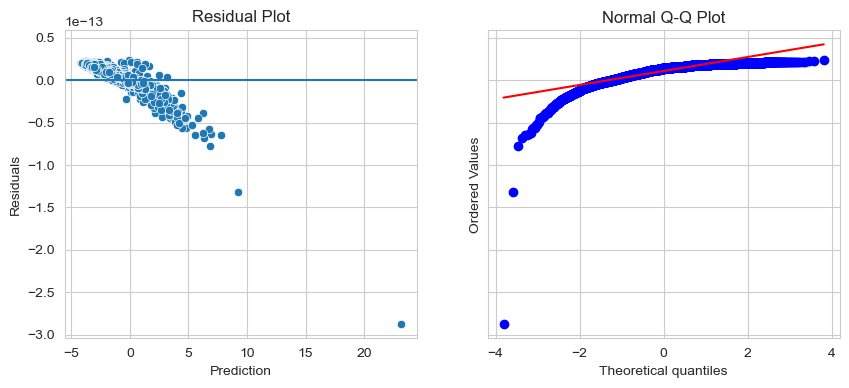

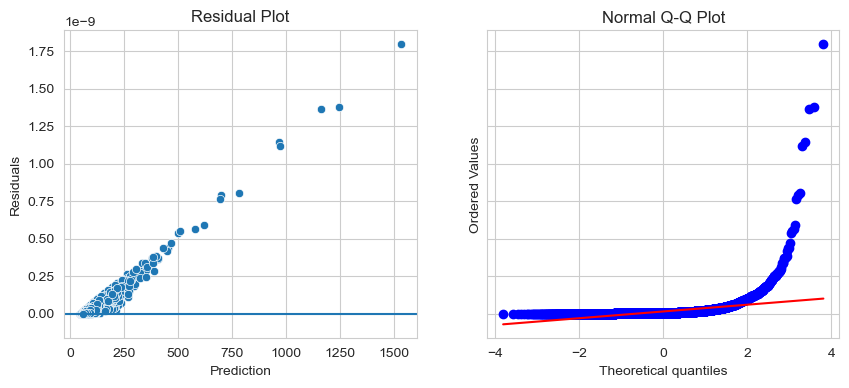

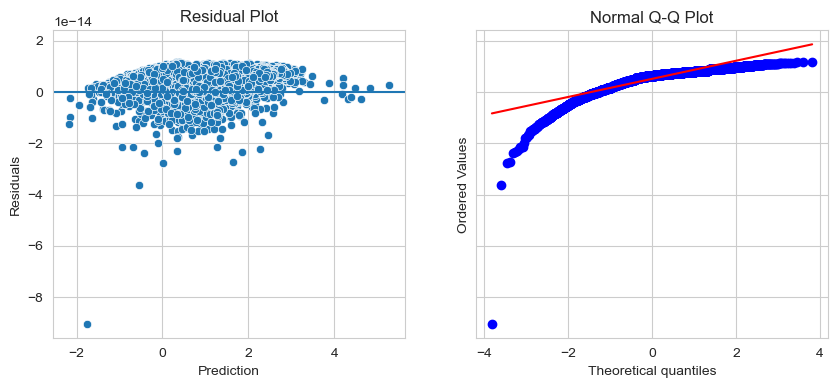

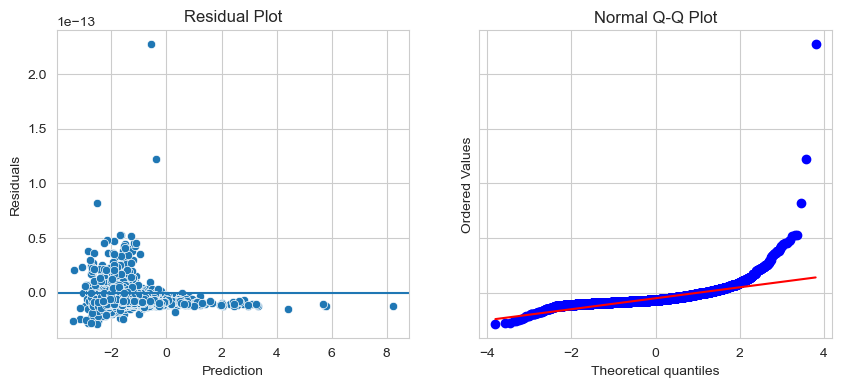

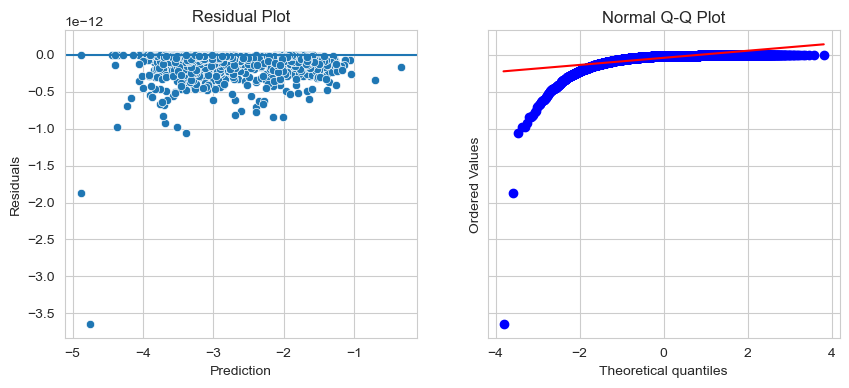

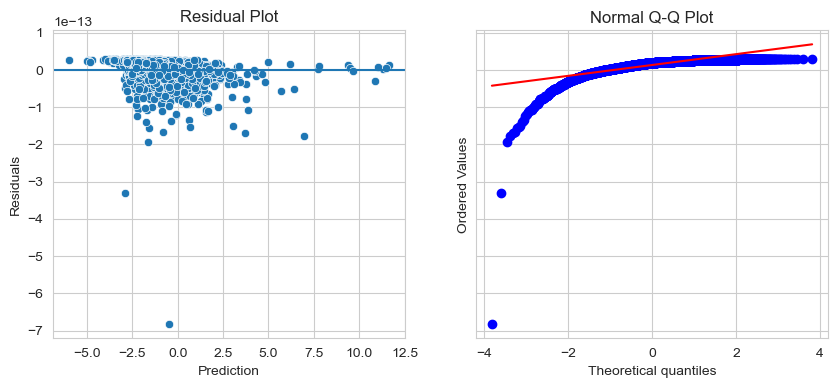

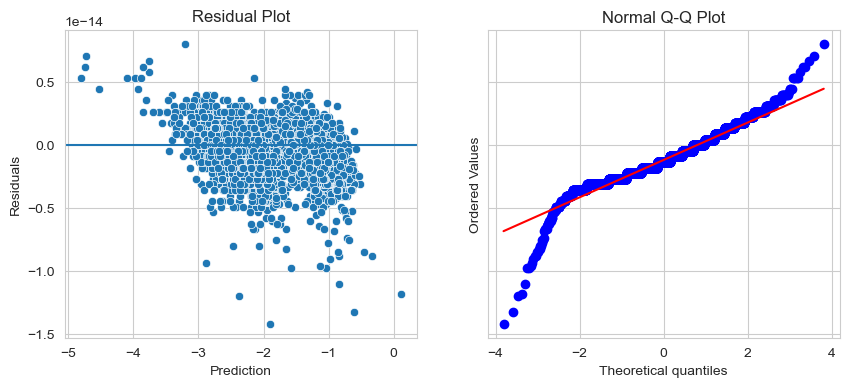

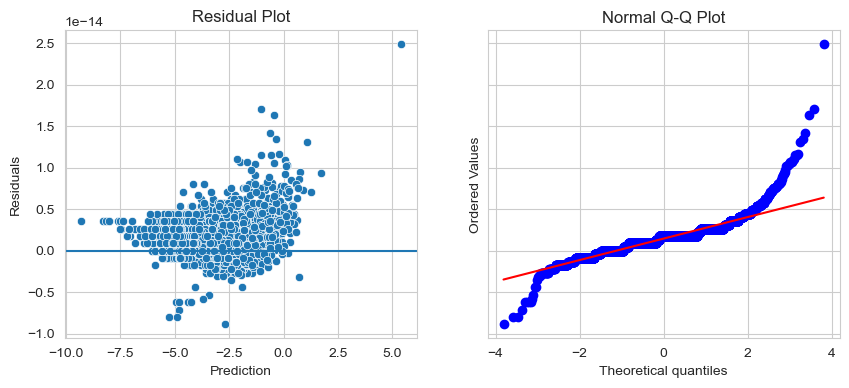

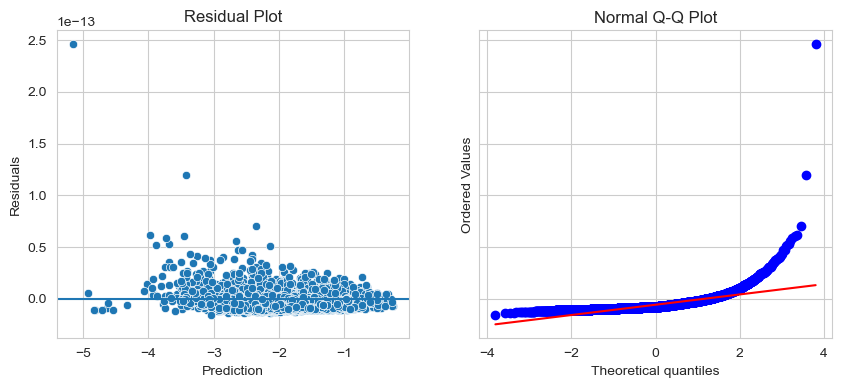

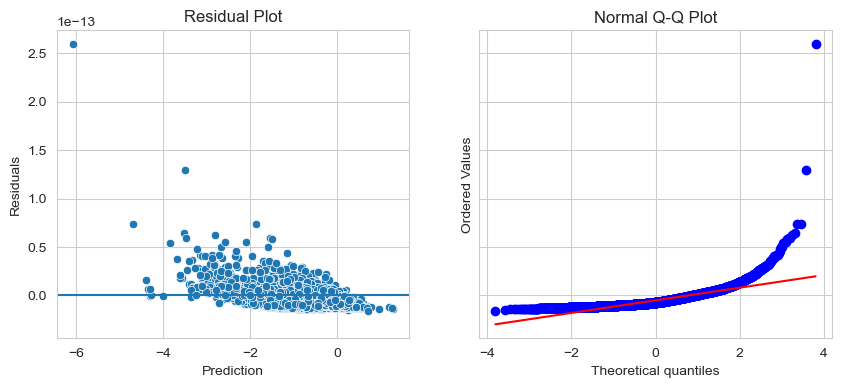

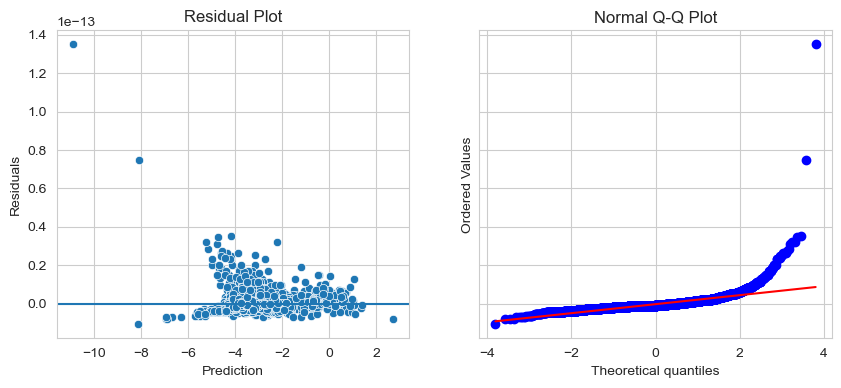

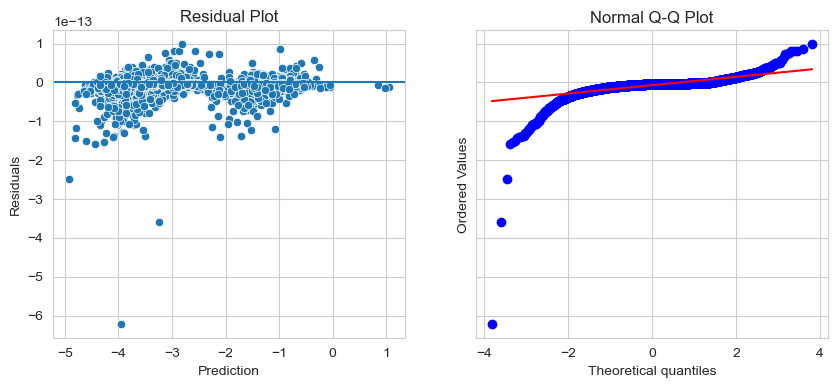

In [186]:
for model in model_list:
    residual_analysis_plot(model)